In [1]:
import os
import pandas as pd
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'/Users/ryan/github/prosodic')
# !pip install -r /Users/ryan/github/prosodic/requirements.txt

import prosodic


In [25]:


df=pd.read_pickle('data.allpoems.pkl')

def filter_poem_txt(txt):
    vparas = [para.strip() for para in txt.split('\n\n') if '\n' in para.strip()]
    return '\n\n'.join(vparas)

def num_lines_txt(txt):
    return len([v for v in txt.splitlines() if v.strip()])

df['poem_txt'] = df['poem'].apply(filter_poem_txt)
df['num_lines_txt'] = df['poem_txt'].apply(num_lines_txt)

df['prompt'] = df['prompt'].fillna('')
df_sonnets = df[df.prompt.str.contains('sonnet') | (df.prompt == '')]
df_sonnets = df_sonnets[df_sonnets.num_lines==14]
df_sonnets.model.value_counts()
# list(df_sonnets.columns)

shaksonnets = prosodic.Text(fn='/Users/ryan/github/prosodic/corpora/corppoetry_en/en.shakespeare.txt')
ld_shak = []
for stanza in shaksonnets.stanzas:
    d = {'model':'shakespeare', 'poem_txt':stanza.txt.strip(), 'num_lines_txt':len(stanza.lines)}
    ld_shak.append(d)

df_shak = pd.DataFrame(ld_shak)
df_shak['poem'] = df_shak['poem_txt']
df_shak['num_lines'] = df_shak['num_lines_txt']

df_markov = pd.read_pickle('data.markov_sonnets.pkl')

df_sonnets2 = pd.concat([df_sonnets, df_shak, df_markov])
# df_sonnets2 = pd.conca
df_sonnets2

,model,temp,prompt,poem,num_lines,num_rhyming_lines,perc_rhyming_lines,prompt_type,_id,_corpus,...,cell,target,bo,bnote,video,pndfig,ybin,path_txt,poem_txt,num_lines_txt
12,claude-3-haiku-20240307,0.847735,Write an ryhmed poem in the style of Shakespea...,Here is an original Shakespearean-style sonnet...,14.0,6.0,42.857143,DO_rhyme,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,When spring's first blossoms fill the air with...,14
24,claude-3-haiku-20240307,0.518403,Write an ryhmed poem in the style of Shakespea...,Here is an original Shakespearean-style sonnet...,14.0,5.0,35.714286,DO_rhyme,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,When winter's chill doth pierce the weary soul...,14
69,claude-3-haiku-20240307,0.733875,Write an ryhmed poem in the style of Shakespea...,Here is an original Shakespearean-style sonnet...,14.0,4.0,28.571429,DO_rhyme,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,When spring's fair blossoms grace the verdant ...,14
79,claude-3-sonnet-20240229,0.681107,Write an ryhmed poem in the style of Shakespea...,Here is an original rhymed poem in the style o...,14.0,2.0,14.285714,DO_rhyme,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"When golden sunbeams filter through the trees,...",14
84,claude-3-haiku-20240307,0.938724,Write an ryhmed poem in the style of Shakespea...,Here is an original rhymed poem in the style o...,14.0,6.0,42.857143,DO_rhyme,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"When autumn's chill pervades the fading light,...",14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,human-markov,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have stood on the nocturnal Walks?\nChaste C...,14
304,human-markov,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,There are four seasons in the first pools.\nWh...,14
305,human-markov,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Cried myself dry and jumped back on the way,\n...",14
306,human-markov,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,You pin her to the read and green see-saws.\nI...,14


In [133]:
df_sonnets_smpl = pd.concat(gdf.sample(frac=1).iloc[:154] for _,gdf in df_sonnets2.groupby('model'))
dict(df_sonnets_smpl.model.value_counts())

{'b. 1600-1650': 154,
 'b. 1900-1950': 154,
 'shakespeare': 154,
 'human-markov': 154,
 'b. 1650-1700': 154,
 'shakespeare-markov': 154,
 'b. 1850-1900': 154,
 'b. 1800-1850': 154,
 'b. 1750-1800': 154,
 'b. 1700-1750': 154,
 'b. 1950-2000': 146,
 'claude-3-haiku-20240307': 65,
 'gpt-3.5-turbo': 50,
 'claude-3-sonnet-20240229': 13,
 'gpt-4-turbo': 13,
 'claude-3-opus-20240229': 6,
 'gemini-pro': 3}

In [134]:
constraints={
    'w_peak':1,
    'w_stress':1,
    's_unstress':1,
    'unres_across':1,
    'unres_within':1,
    'pentameter':1000,
    'iambic':1000,
}

meter = prosodic.Meter(
    constraints=constraints,
    resolve_optionality=True,
    max_s=1,
    max_w=2,
)

# parses = shaksonnets.parse(meter=meter)

In [136]:
parses = []
parse_dfs = []

parse_stash = prosodic.HashStash('sonnet_parses_iambic_pentameter', serializer='pickle', engine='lmdb')
# parse_stash.clear()

# @parse_stash.stashed_result
def get_parses_df(force=False):
    fn='data.sonnet_parses_iambic_pentameter.pkl'
    if not force and os.path.exists(fn):
        return pd.read_pickle(fn)
    for stanza_i,(i,row) in enumerate(prosodic.progress_bar(list(df_sonnets_smpl[['poem_txt','model']].iterrows()), desc='Parsing sonnets')):
        try:
            stanza = prosodic.Text(txt=row.poem_txt)
        except Exception as e:
            print(e)
            continue
        for line_i,line in enumerate(stanza.lines):
            try:
                if line.wordforms_first.num_sylls != 10: continue
                line_txt = line.txt.strip()
                parse_df = parse_stash.get(line_txt)
                if parse_df is None:
                    parse = prosodic.Parse(line_txt, scansion="-+-+-+-+-+")
                
                    parse_df = parse.df
                    parse_df['stanza_num'] = stanza_i+1
                    parse_df['line_num'] = line_i+1

                    parse_stash.set(line_txt, parse_df)
                parse_df = parse_df.assign(model = row.model)
                parse_dfs.append(parse_df)
            except Exception as e:
                print(e)
                continue

    parses_df = pd.concat(parse_dfs)
    parses_df.to_pickle(fn)
    return parses_df

parses_df = get_parses_df()
dict(parses_df.agent.value_counts())

AttributeError: 'DataFrame' object has no attribute 'agent'

In [28]:
# df=stats_by_line.reset_index()
# df.query('parse_meter=="-+-+-+-+-+"')['line_num'].nunique()

# stats_by_syll['*total'] = stats_by_syll[[c for c in stats_by_syll.columns if c.startswith('*') and c not in {'*pentameter'}]].sum(axis=1).apply(bool).apply(int)
# stats_by_syll


In [261]:
import plotnine as p9

figdf = parses_df.reset_index()

def get_agent(model):
    if model == 'shakespeare':
        return 'Shakes'
    elif model.startswith('b.'):
        cents = int(model[3:5])+1
        if cents in {17,18,19}:
            return 'C17-19'
        else:
            return f'C{cents}   '
    elif model == 'shakespeare-markov':
        return 'Markov'
    elif model == 'human-markov':
        return 'Markov2'
    else:
        return 'LLM   '

figdf['agent'] = figdf['model'].apply(get_agent)
figdf = figdf[~figdf['agent'].isin({'Markov2'})]

figdf = pd.concat(
    gdf.assign(meter_syll_num=gdf.sort_values(['meterpos_num', 'meterslot_num']).groupby(['meterpos_num','meterslot_num']).ngroup() + 1)
    for g,gdf in figdf.groupby(['stanza_num','line_num','parse_meter','parse_rank'])
)

def get_line_num_type(line_num):
    if line_num in [1,2,3,4]:
        return 'Q1'
    elif line_num in [5,6,7,8]:
        return 'Q2'
    elif line_num in [9,10,11,12]:
        return 'Q3'
    elif line_num in [13,14]:
        return 'CC'

figdf['line_num_type'] = figdf['line_num'].apply(get_line_num_type)

# Get violation columns (those starting with *)
viol_cols = [col for col in figdf.columns if col.startswith('*')]

# Melt the DataFrame
figdf_melted = pd.melt(
    figdf,
    id_vars=['meter_syll_num','line_num','agent'],
    value_vars=viol_cols,
    var_name='violation_type',
    value_name='violation_value'
)
figdf_melted['violation_value']*=100
# Clean up violation_type names by removing the *
figdf_melted['violation_type'] = figdf_melted['violation_type'].str.replace('*', '')

p9.options.figure_size = (8, 6)
figdf_melted['label'] = figdf_melted['violation_value'].apply(lambda x: f'{int(round(x*100))}%')

violnames = {
    's_unstress': '*Lapse (Missing stress in strong position)',
    'w_stress': '*Clash (Unexpected stress in weak position)',
    'w_peak': '*Peak (Unexpected polysyllabic stress in weak position)',
    # 'unres_across': '*Unresolved across',
    # 'unres_within': '*Unresolved within',
}

figdf_melted['violation_type'] = figdf_melted['violation_type'].apply(lambda x: violnames.get(x, x))
figdf_melted['meter_syll_num'] = pd.Categorical(figdf_melted['meter_syll_num'].astype(int))

figdf_melted = figdf_melted[figdf_melted.violation_type.isin(set(violnames.values()))]
figdf_melted['violation_type'] = pd.Categorical(figdf_melted['violation_type'], categories=list(violnames.values()))
figdf_melted.agent.value_counts()

agent
C17-19     248790
LLM         50760
Shakes      50010
C20         38010
Markov2     29400
Markov      17040
Name: count, dtype: int64

In [262]:

import numpy as np
# Calculate mean and standard error for the line plot
line_data = (figdf_melted
             .groupby(['meter_syll_num','violation_type','agent'])
             .agg({
                 'violation_value': ['mean', 'std', 'count']
             })
             .reset_index())
line_data.columns = ['meter_syll_num', 'violation_type', 'agent', 'mean', 'std', 'count']
line_data['violation_value'] = line_data['mean']
line_data['se'] = line_data['std'] / np.sqrt(line_data['count'])
def safe_add(a, b):
    try:
        return a + b
    except TypeError:
        return float('nan')

def safe_subtract(a, b):
    try:
        return a - b
    except TypeError:
        return float('nan')

line_data['upper'] = line_data.apply(lambda row: safe_add(row['mean'], row['se']), axis=1)
line_data['lower'] = line_data.apply(lambda row: safe_subtract(row['mean'], row['se']), axis=1)
line_data['group'] = line_data['agent'].astype(str)# + '_' + line_data['violation_type'].astype(str)
line_data = line_data.query('mean>0')
line_data = line_data.sort_values(['group','meter_syll_num'])
line_data

,meter_syll_num,violation_type,agent,mean,std,count,violation_value,se,upper,lower,group
6,1,*Clash (Unexpected stress in weak position),C17-19,23.115881,42.159915,8293,23.115881,0.462960,23.578841,22.652920,C17-19
12,1,*Peak (Unexpected polysyllabic stress in weak ...,C17-19,6.342699,24.374406,8293,6.342699,0.267657,6.610355,6.075042,C17-19
18,2,*Lapse (Missing stress in strong position),C17-19,37.212107,48.339958,8293,37.212107,0.530824,37.742930,36.681283,C17-19
42,3,*Clash (Unexpected stress in weak position),C17-19,14.952369,35.662543,8293,14.952369,0.391612,15.343982,14.560757,C17-19
48,3,*Peak (Unexpected polysyllabic stress in weak ...,C17-19,1.531412,12.280642,8293,1.531412,0.134854,1.666266,1.396558,C17-19
...,...,...,...,...,...,...,...,...,...,...,...
125,7,*Peak (Unexpected polysyllabic stress in weak ...,Shakes,1.559688,12.394690,1667,1.559688,0.303576,1.863264,1.256112,Shakes
131,8,*Lapse (Missing stress in strong position),Shakes,34.553089,47.568375,1667,34.553089,1.165066,35.718155,33.388023,Shakes
155,9,*Clash (Unexpected stress in weak position),Shakes,9.838032,29.791757,1667,9.838032,0.729673,10.567705,9.108359,Shakes
161,9,*Peak (Unexpected polysyllabic stress in weak ...,Shakes,1.979604,13.934061,1667,1.979604,0.341279,2.320883,1.638325,Shakes


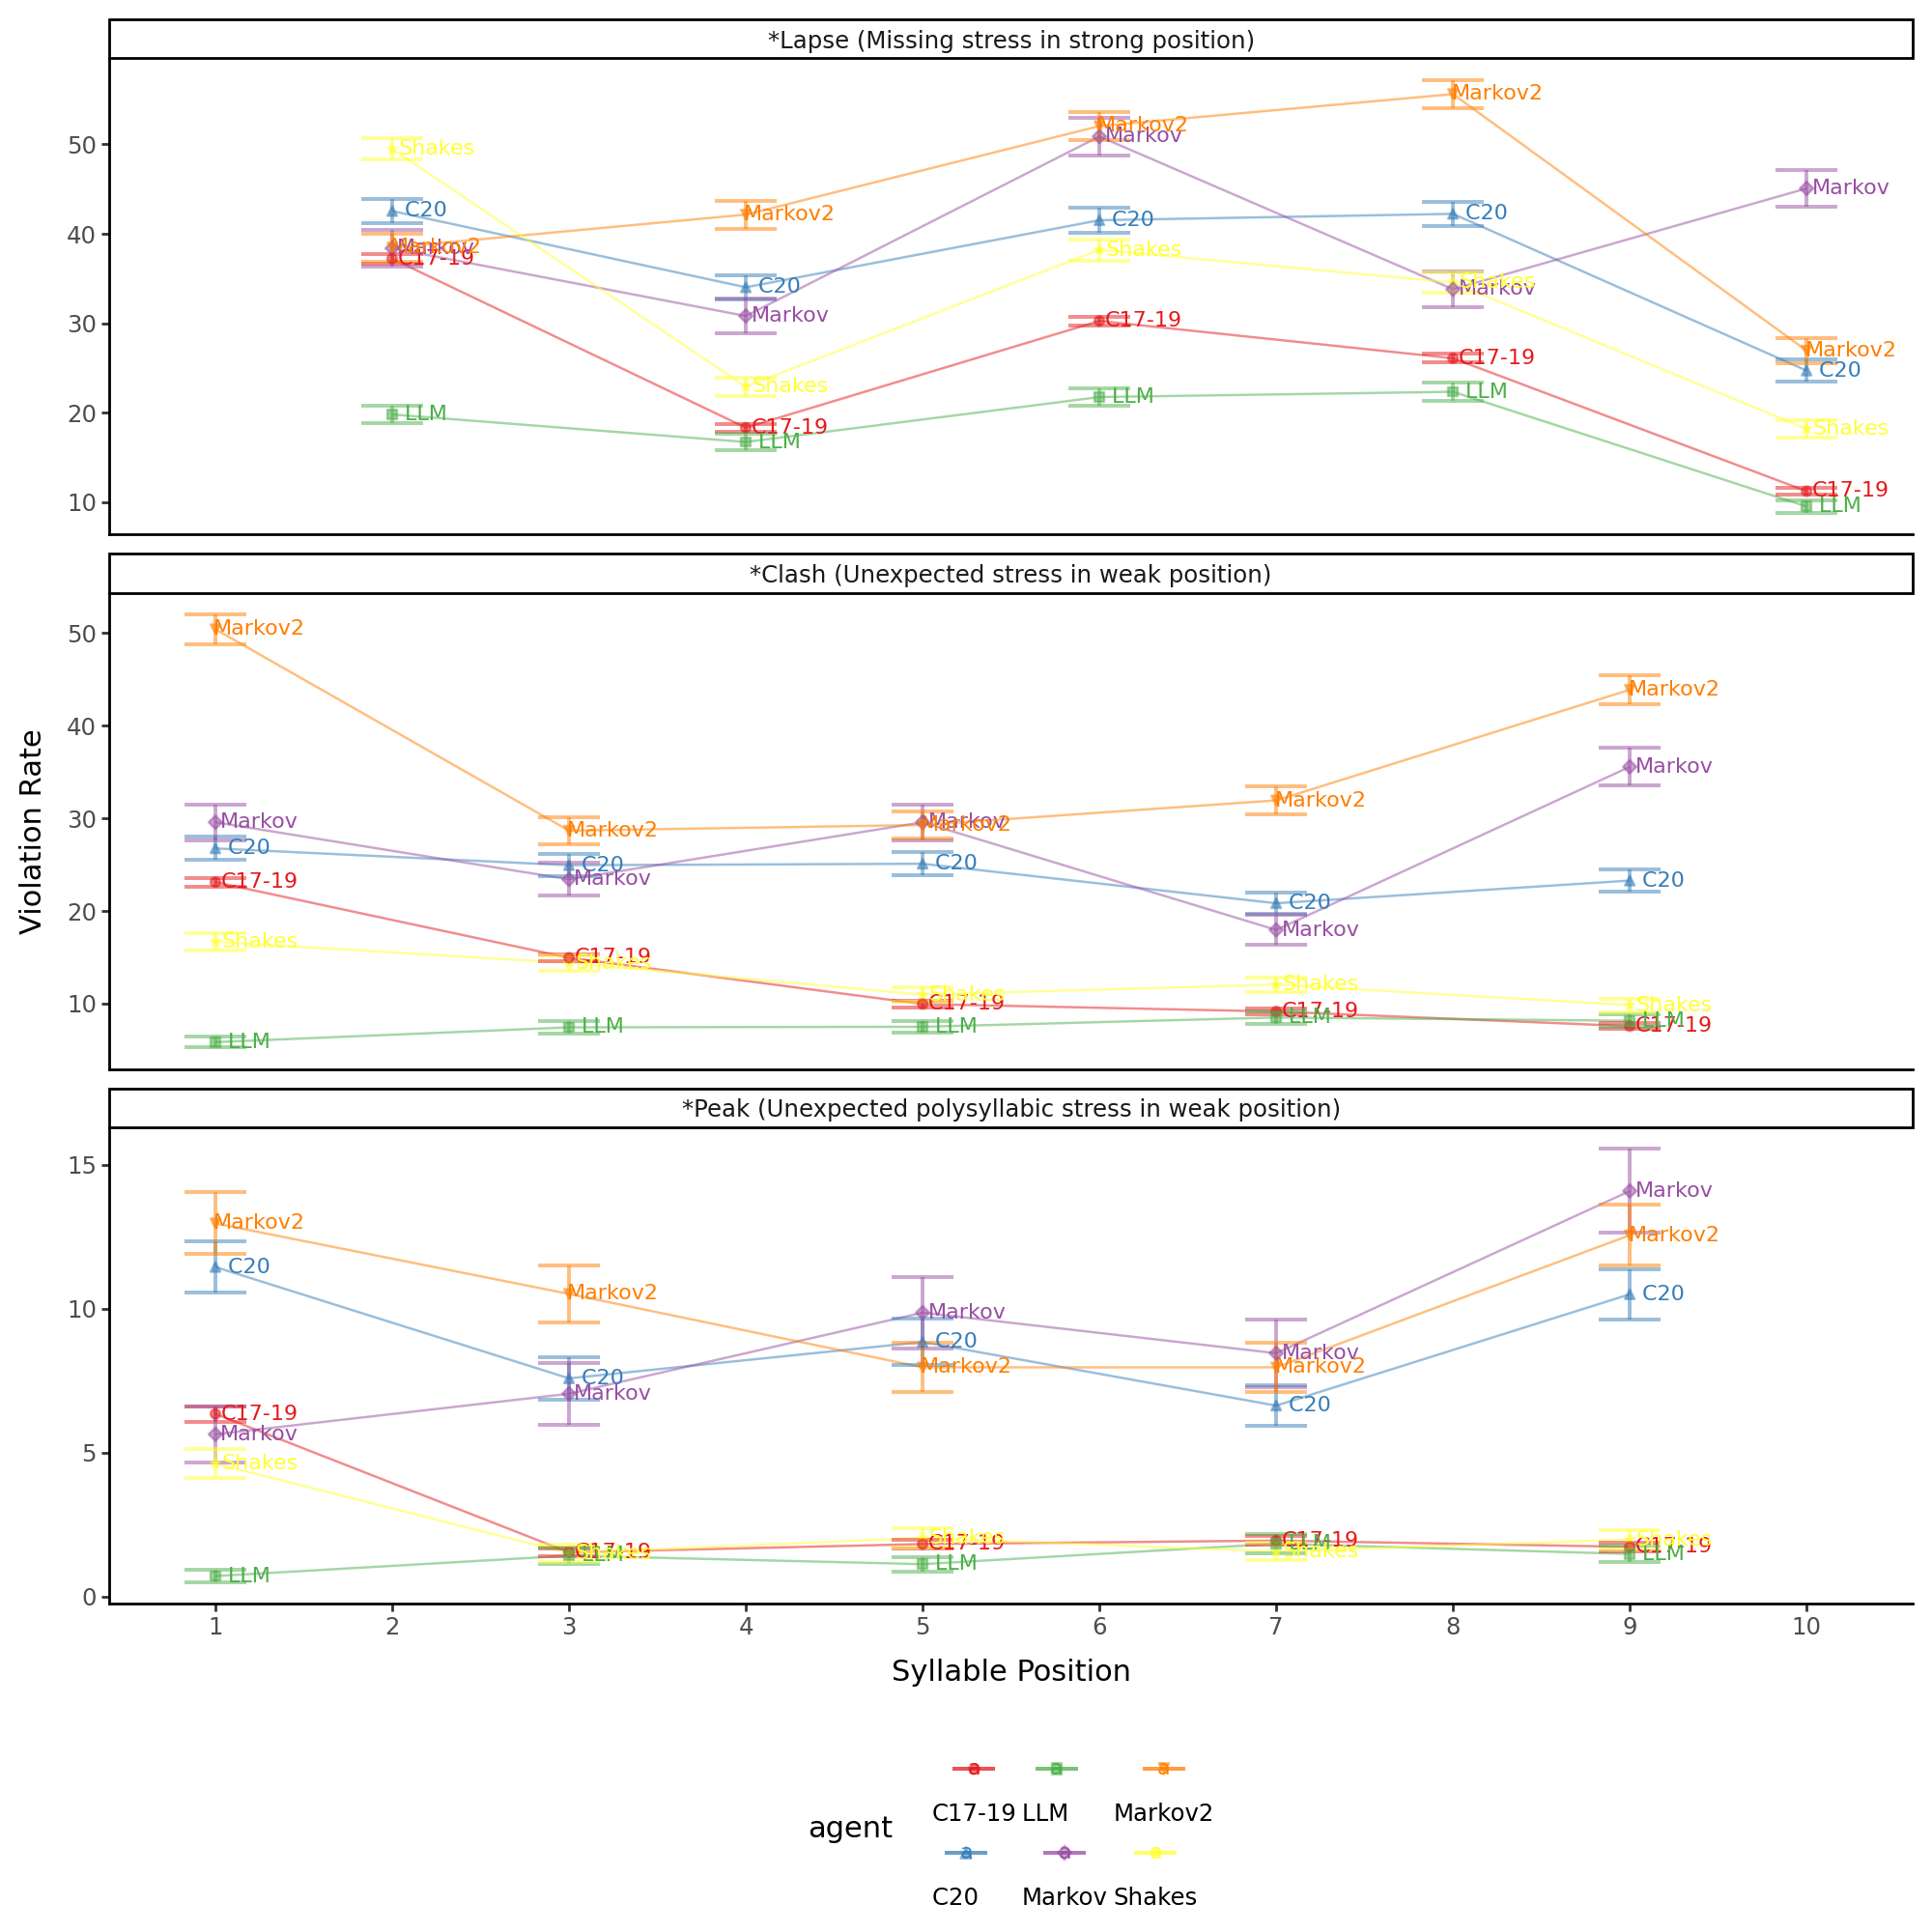

In [263]:
figdf_now = figdf_melted#.query('label != "0%"')
# line_data['line_count'] = line_data['count'] / 14


p9.options.figure_size = (10, 10)

fig = (p9.ggplot(figdf_now, 
                 p9.aes(x='meter_syll_num', 
                        y='violation_value',
                        color='agent')) + 
       p9.geom_line(p9.aes(group='agent'), size=.5, data=line_data, alpha=.5) +
 
       p9.geom_errorbar(p9.aes(ymin='lower', ymax='upper'), data=line_data, width=.35, size=.8, alpha=.5) +
       p9.geom_text(p9.aes(label='agent'),size=8, data=line_data.query('mean>0'), position=p9.position_nudge(x=.25)) +
       p9.geom_point(p9.aes(shape='agent'), data=line_data, alpha=.5) +
       p9.scale_size_continuous(range=[1,3]) +
       p9.theme_classic() +
#        p9.facet_grid('violation_type~agent', scales='free_y') +
#        p9.facet_wrap('agent', scales='free_y') +
       p9.facet_wrap('violation_type', ncol=1, scales='free_y') +
       p9.scale_color_brewer(type='qual', palette='Set1') +
       p9.labs(x='Syllable Position', 
               y='Violation Rate',
               fill='Violation Type'))
fig = fig + p9.theme(legend_position='bottom')

fig